In [1]:
import warnings 
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta, date
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point
import math

In [2]:
#Lectura de los datos en bruto y eliminación de espacios
metadata=pd.read_csv("../Datos en bruto/Meteorologicos/Temperatura/stations.txt",skiprows=17,sep=",")
metadata.columns=metadata.columns.str.strip()
metadata.CN=metadata.CN.str.strip()
metadata.STANAME=metadata.STANAME.str.strip()
metadata

,STAID,STANAME,CN,LAT,LON,HGHT
0,1,VAEXJOE,SE,+56:52:00,+014:48:00,166
1,2,FALUN,SE,+60:37:00,+015:37:00,160
2,3,STENSELE,SE,+65:04:00,+017:09:59,325
3,4,LINKOEPING,SE,+58:24:00,+015:31:59,93
4,5,LINKOEPING-MALMSLAETT,SE,+58:24:00,+015:31:59,93
...,...,...,...,...,...,...
9698,27950,E6 SEFRIVATNET,NO,+65:15:11,+013:18:55,308
9699,27951,E6 HANSMYRAN,NO,+65:12:07,+013:22:45,368
9700,27952,FV659 REMMEFJELL,NO,+62:32:26,+006:28:45,124
9701,27953,E75 DOMEN,NO,+70:20:02,+031:01:26,103


In [3]:
#Filtrado de datos para España
metadata_ESP=metadata[metadata.CN=='ES']
metadata_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
183,229,BADAJOZ AEROPUERTO,ES,+38:52:59,-006:48:50,186
185,231,MALAGA AEROPUERTO,ES,+36:39:57,-004:28:55,7
186,232,PUERTO DE NAVACERRADA,ES,+40:47:35,-004:00:38,1893
187,233,SALAMANCA AEROPUERTO,ES,+40:57:33,-005:29:53,790
189,235,TORREVIEJA,ES,+37:58:37,-000:42:38,1
...,...,...,...,...,...,...
9490,27679,MIRANDA DE EBRO,ES,+42:24:41,+002:34:24,460
9491,27683,VALDEZCARAY,ES,+42:09:06,+002:34:49,1630
9492,27684,MEDINA DE POMAR,ES,+42:33:03,+003:17:08,580
9495,27696,BRIVIESCA,ES,+42:19:59,+003:10:59,730


In [4]:
#Funcion para transformación de longitudes y latitudes a formato decimal
def dms_a_decimal(dms_str):
    # Quitar el signo y dividir en partes
    signo = -1 if dms_str.startswith("-") else 1
    partes = dms_str.lstrip("+-").split(":")
    grados, minutos, segundos = map(float, partes)
    decimal = signo * (grados + minutos / 60 + segundos / 3600)
    return decimal

In [5]:
#Transformación de las variables
metadata_ESP['LAT'] = metadata_ESP['LAT'].apply(dms_a_decimal)
metadata_ESP['LON'] = metadata_ESP['LON'].apply(dms_a_decimal)
metadata_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
183,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
185,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
186,232,PUERTO DE NAVACERRADA,ES,40.793056,-4.010556,1893
187,233,SALAMANCA AEROPUERTO,ES,40.959167,-5.498056,790
189,235,TORREVIEJA,ES,37.976944,-0.710556,1
...,...,...,...,...,...,...
9490,27679,MIRANDA DE EBRO,ES,42.411389,2.573333,460
9491,27683,VALDEZCARAY,ES,42.151667,2.580278,1630
9492,27684,MEDINA DE POMAR,ES,42.550833,3.285556,580
9495,27696,BRIVIESCA,ES,42.333056,3.183056,730


In [6]:
#Carga de mapas para obtener mapa de España
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres")) #Carga de países
spain = world[world["name"] == "Spain"] #Mapa de España

In [7]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(metadata_ESP['LON'], metadata_ESP['LAT'])] 
puntos = gpd.GeoDataFrame(metadata_ESP, geometry=estaciones, crs="EPSG:4326") 

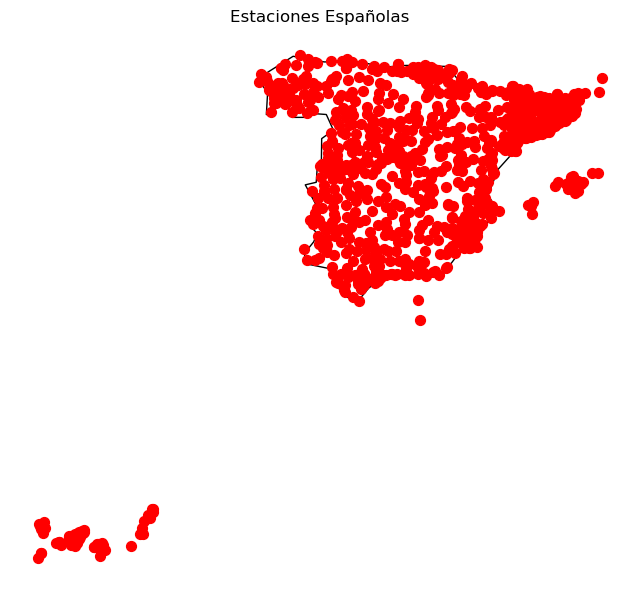

In [8]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas")
plt.axis("off")
plt.show()

In [9]:
#Lista de IDs de estaciones españolas
lista_estaciones_espanolas=metadata_ESP.STAID.to_list()

In [10]:
#Definición del dataframe con información de la primera estación
station='TG_STAID000000'
station_i=station[:-len(str(lista_estaciones_espanolas[0]))]+str(lista_estaciones_espanolas[0])
data=pd.read_csv('../Datos en bruto/Meteorologicos/Temperatura/'+str(station_i)+'.txt',skiprows=20,sep=",")
data.columns=data.columns.str.strip()
data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
data=data[(data.DATE>='2013-01-01') & (data.Q_TG!=9)]
data_unif=data.loc[:,['DATE','TG']]
data_unif.set_index('DATE', inplace=True)
data_unif

,TG
DATE,
2013-01-01,96
2013-01-02,66
2013-01-03,86
2013-01-04,83
2013-01-05,83
...,...
2025-03-25,132
2025-03-26,134
2025-03-27,128


In [11]:
#Anexión de la información del resto de estaciones meteorológicas
for i in lista_estaciones_espanolas[1:]:
    station='TG_STAID000000'
    station_i=station[:-len(str(i))]+str(i)
    data=pd.read_csv('../Datos en bruto/Meteorologicos/Temperatura/'+station_i+'.txt',skiprows=20,sep=",")
    data.columns=data.columns.str.strip()
    data['DATE'] = pd.to_datetime(data['DATE'],format='%Y%m%d')
    data=data[(data.DATE>='2008-01-01') & (data.Q_TG!=9)]
    df=data.loc[:,['DATE','TG']]
    df.set_index('DATE', inplace=True)
    data_unif['TG '+str(i)]=df

data_unif

,TG,TG 231,TG 232,TG 233,TG 235,TG 236,TG 237,TG 309,TG 336,TG 337,...,TG 27664,TG 27665,TG 27667,TG 27670,TG 27672,TG 27679,TG 27683,TG 27684,TG 27696,TG 27700
DATE,,,,,,,,,,,,,,,,,,,,,
2013-01-01,96,138,-10,58.0,NaN,104,142,116.0,36.0,86.0,...,78.0,78.0,52.0,37.0,64.0,80.0,3.0,74.0,62.0,45.0
2013-01-02,66,140,-24,38.0,NaN,118,123,120.0,46.0,86.0,...,70.0,70.0,38.0,12.0,62.0,64.0,-16.0,70.0,52.0,35.0
2013-01-03,86,119,-7,36.0,NaN,104,102,108.0,29.0,90.0,...,58.0,58.0,56.0,29.0,74.0,67.0,22.0,60.0,58.0,62.0
2013-01-04,83,116,58,41.0,NaN,108,134,102.0,40.0,91.0,...,64.0,64.0,73.0,71.0,86.0,56.0,66.0,48.0,68.0,76.0
2013-01-05,83,135,80,48.0,NaN,128,148,134.0,61.0,91.0,...,72.0,72.0,77.0,88.0,100.0,66.0,69.0,42.0,74.0,99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,132,164,0,82.0,NaN,162,147,147.0,114.0,122.0,...,88.0,90.0,59.0,74.0,88.0,103.0,10.0,88.0,81.0,58.0
2025-03-26,134,158,5,82.0,NaN,160,154,146.0,91.0,130.0,...,84.0,86.0,34.0,58.0,78.0,92.0,-4.0,64.0,68.0,44.0
2025-03-27,128,168,10,72.0,NaN,156,142,140.0,92.0,142.0,...,82.0,84.0,39.0,64.0,67.0,84.0,-3.0,63.0,66.0,46.0


In [12]:
# Se eliminan todas aquellas estaciones que tienen datos faltantes y se renombra la primera estación con el IDs de estación
d=data_unif.dropna(axis=1)
d=d.rename({'TG':'TG 229'},axis=1)
d

,TG 229,TG 231,TG 232,TG 236,TG 237,TG 420,TG 421,TG 424,TG 425,TG 1393,...,TG 26989,TG 27045,TG 27046,TG 27106,TG 27232,TG 27422,TG 27450,TG 27460,TG 27610,TG 27631
DATE,,,,,,,,,,,,,,,,,,,,,
2013-01-01,96,138,-10,104,142,126,105,46,68,102,...,46,118,116,109,56,141,76,114,44,58
2013-01-02,66,140,-24,118,123,113,112,42,46,84,...,46,116,110,100,56,138,82,124,52,68
2013-01-03,86,119,-7,104,102,120,104,51,63,84,...,58,98,109,116,58,130,78,116,44,58
2013-01-04,83,116,58,108,134,126,106,64,50,79,...,106,90,116,110,51,126,82,118,58,82
2013-01-05,83,135,80,128,148,116,128,78,25,62,...,140,68,90,96,46,152,86,141,88,107
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-25,132,164,0,162,147,131,154,79,90,126,...,63,127,122,137,108,155,98,144,94,124
2025-03-26,134,158,5,160,154,126,161,54,90,113,...,80,104,120,128,92,164,118,148,102,102
2025-03-27,128,168,10,156,142,119,167,68,76,115,...,72,105,114,119,85,196,122,149,96,100


In [13]:
# Lista de estaciones españolas sin valores faltantes
v=[]
for i in d.columns:
    v.append(int(i[3:]))
    
mt=metadata_ESP[metadata_ESP.STAID.isin(v)]
mt

,STAID,STANAME,CN,LAT,LON,HGHT
183,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
185,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
186,232,PUERTO DE NAVACERRADA,ES,40.793056,-4.010556,1893
190,236,ESTACION DE TORTOSA (ROQUETES),ES,40.820278,0.493056,50
191,237,VALENCIA,ES,39.480556,-0.366389,11
312,420,A CORUNA,ES,43.365556,-8.421389,57
313,421,MURCIA,ES,38.001667,-1.170556,62
316,424,SORIA,ES,41.775000,-2.483056,1081
317,425,VALLADOLID,ES,41.640556,-4.754167,734
629,1393,BILBAO AEROPUERTO,ES,43.298056,-2.906389,42


In [14]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt['LON'], mt['LAT'])] 
puntos = gpd.GeoDataFrame(mt, geometry=estaciones, crs="EPSG:4326") 

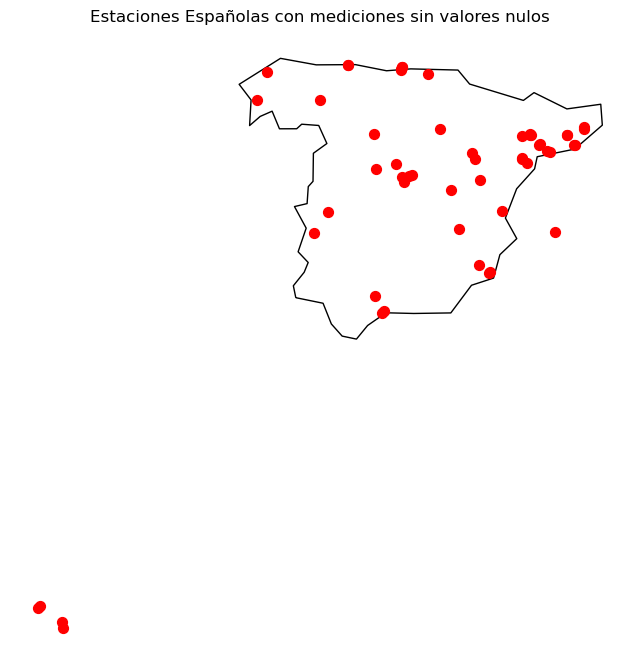

In [15]:
#Gráfica con todas las estaciones
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas con mediciones sin valores nulos")
plt.axis("off")
plt.show()

In [16]:
#Primer filtrado de estaciones en función del valor truncado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt['LON'],mt['LAT'],mt['STAID']):
    if (math.trunc(x[0]),math.trunc(x[1])) not in w:
        w.append((math.trunc(x[0]),math.trunc(x[1])))
        ww.append(x[2])

mt_esp=mt[mt.STAID.isin(ww)]

In [17]:
#Segundo filtrado de estaciones en función del valor redondeado de la longitud y latitud
w=[]
ww=[]
for x in zip(mt_esp['LON'],mt_esp['LAT'],mt_esp['STAID']):
    if (round(x[0]),round(x[1])) not in w:
        w.append((round(x[0]),round(x[1])))
        ww.append(x[2])
        
mt_ESP=mt_esp[mt_esp.STAID.isin(ww)]
mt_ESP

,STAID,STANAME,CN,LAT,LON,HGHT
183,229,BADAJOZ AEROPUERTO,ES,38.883056,-6.813889,186
185,231,MALAGA AEROPUERTO,ES,36.665833,-4.481944,7
186,232,PUERTO DE NAVACERRADA,ES,40.793056,-4.010556,1893
190,236,ESTACION DE TORTOSA (ROQUETES),ES,40.820278,0.493056,50
191,237,VALENCIA,ES,39.480556,-0.366389,11
312,420,A CORUNA,ES,43.365556,-8.421389,57
313,421,MURCIA,ES,38.001667,-1.170556,62
316,424,SORIA,ES,41.775000,-2.483056,1081
317,425,VALLADOLID,ES,41.640556,-4.754167,734
629,1393,BILBAO AEROPUERTO,ES,43.298056,-2.906389,42


In [22]:
#Transformacion de latitudes y longitudes en puntos
estaciones = [Point(xy) for xy in zip(mt_ESP['LON'], mt_ESP['LAT'])] 
puntos = gpd.GeoDataFrame(mt_ESP, geometry=estaciones, crs="EPSG:4326") 

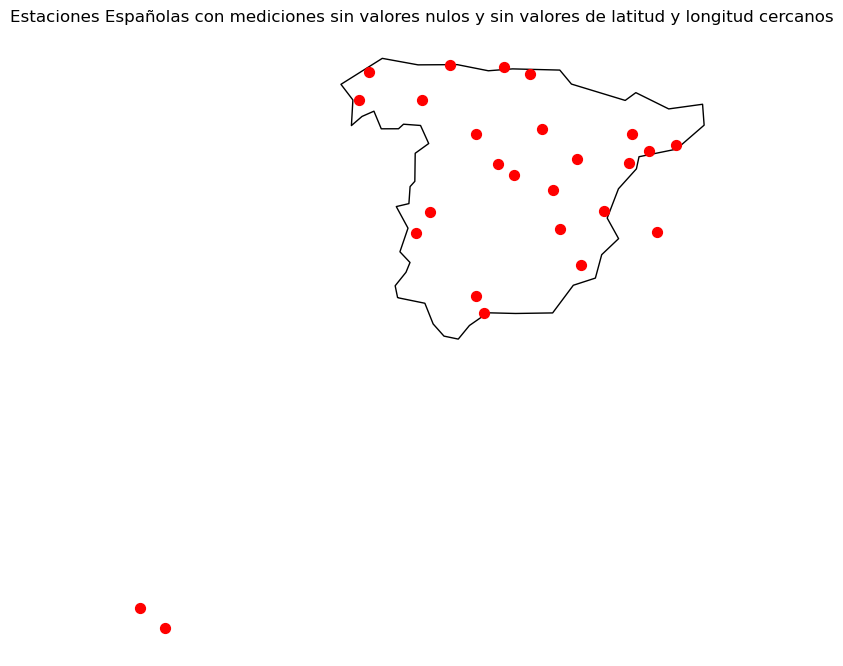

In [23]:
#Gráfica
fig, ax = plt.subplots(figsize=(8, 10))
spain.plot(ax=ax, color="white", edgecolor="black")
puntos.plot(ax=ax, color="red", markersize=50)
plt.title("Estaciones Españolas con mediciones sin valores nulos y sin valores de latitud y longitud cercanos")
plt.axis("off")
plt.show()

In [18]:
#Agrupación de los datos diarios en datos semanales para cada estación
data=d.loc[:,['TG '+str(i) for i in mt_ESP.STAID.to_list()]]
data=data.resample('W').mean()
data

,TG 229,TG 231,TG 232,TG 236,TG 237,TG 420,TG 421,TG 424,TG 425,TG 1393,...,TG 3922,TG 3929,TG 3942,TG 3959,TG 3964,TG 11034,TG 11207,TG 26867,TG 27106,TG 27450
DATE,,,,,,,,,,,,,,,,,,,,,
2013-01-06,81.666667,136.000000,35.500000,117.000000,132.833333,116.666667,116.333333,60.000000,41.666667,83.833333,...,107.666667,54.333333,36.333333,183.333333,46.333333,96.333333,185.166667,112.666667,102.000000,78.666667
2013-01-13,112.285714,154.285714,14.857143,114.142857,135.285714,109.571429,123.000000,27.142857,41.714286,69.428571,...,95.142857,50.000000,34.428571,177.571429,40.714286,85.000000,180.857143,112.428571,99.142857,80.142857
2013-01-20,108.000000,141.571429,-13.571429,116.142857,146.142857,111.285714,134.285714,36.428571,57.714286,88.571429,...,101.428571,49.571429,79.000000,181.714286,58.714286,90.000000,181.000000,130.571429,106.285714,89.285714
2013-01-27,105.428571,135.714286,-23.857143,98.285714,132.571429,105.571429,122.142857,23.428571,44.142857,75.714286,...,93.285714,39.857143,59.000000,188.571429,30.857143,82.428571,195.000000,108.857143,89.285714,86.142857
2013-02-03,100.285714,141.714286,19.428571,129.000000,150.428571,127.857143,143.142857,55.428571,61.000000,115.571429,...,126.142857,61.285714,84.285714,189.428571,56.857143,113.428571,193.000000,114.142857,115.428571,92.571429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-02,116.285714,146.285714,16.714286,116.142857,139.714286,125.000000,136.142857,51.428571,72.428571,107.000000,...,113.142857,73.000000,96.571429,192.571429,53.000000,114.428571,200.571429,131.000000,120.571429,113.142857
2025-03-09,127.142857,148.714286,4.571429,132.714286,144.428571,131.285714,150.285714,60.428571,95.857143,150.000000,...,150.285714,90.857143,129.000000,185.285714,80.285714,137.857143,185.571429,155.000000,128.571429,113.142857
2025-03-16,117.571429,142.285714,-17.714286,118.428571,137.000000,108.857143,145.428571,39.571429,60.857143,94.142857,...,95.714286,59.428571,93.000000,196.714286,48.857143,111.714286,197.142857,131.857143,109.142857,110.285714


In [19]:
#Cálculo de la media para cada semana en función del total de estaciones
a=data.mean(axis=1)
a=pd.DataFrame(a).rename({0:'TG'},axis=1)
a

,TG
DATE,
2013-01-06,90.564103
2013-01-13,87.884615
2013-01-20,96.631868
2013-01-27,86.423077
2013-02-03,105.708791
...,...
2025-03-02,107.329670
2025-03-09,122.423077
2025-03-16,101.659341


In [20]:
#Cálculo de la media para cada semana en función del total de estaciones
a.to_csv('temperatura_semanal_esp.csv',index=True,encoding='utf-8')

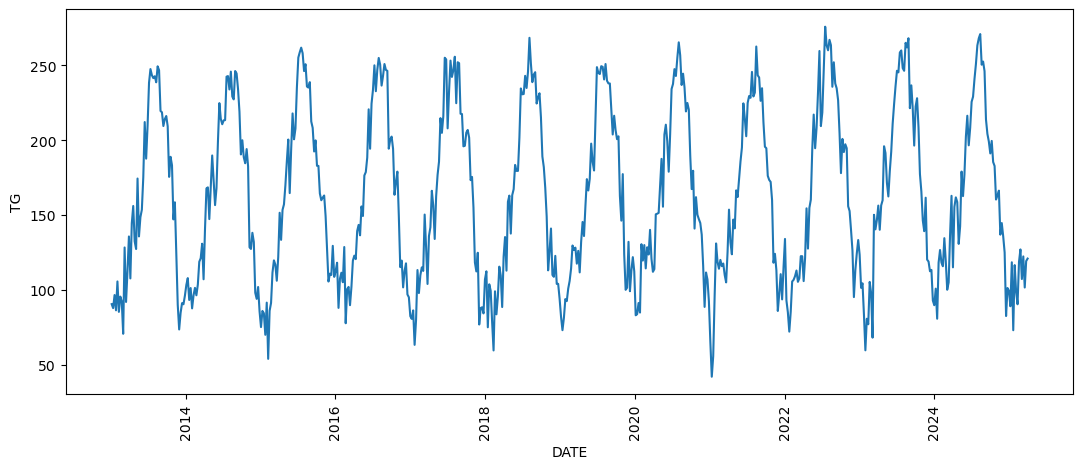

In [21]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=a,x=a.index,y=a.TG)
plt.xticks(rotation=90)
plt.show()